For this assigment, I plan to explore a dataset I have found on homelessness, looking at how Michigan's homelessness compares to some other states.

For this class, I would like to explore my interest in public health as well as social vulnerability I found this dataset of homelessness estimates across states. In this exercise, I plan to to just take a brief overview of the data as well as merge it with a map in order to analyze it visually. In the future I would like to further explore the reasons why some states have higher amounts of homelessness than others by maybe looking at economic data, climatic data, or any other factors that might impact homelessness. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import geodatasets

In [2]:
df = pd.read_csv('C:\\Users\\josep\\OneDrive\\Documents\\GEOG4670\\Week 4-5\\Point_in_Time_Estimates_of_Homelessness_in_the_US_by_State_20260220(Clean).csv')
df.head(55)

,YEAR,STATE,COUNT_TYPE,COUNT
0,2018,AK,Overall Homeless,"2,016"
1,2018,AL,Overall Homeless,"3,434"
2,2018,AR,Overall Homeless,"2,712"
3,2018,AZ,Overall Homeless,"9,865"
4,2018,CA,Overall Homeless,"129,972"
5,2018,CO,Overall Homeless,"10,857"
6,2018,CT,Overall Homeless,"3,976"
7,2018,DC,Overall Homeless,"6,904"
8,2018,DE,Overall Homeless,"1,082"
9,2018,FL,Overall Homeless,"31,030"


In [ ]:
df['STATE'] = df['STATE'].astype(str).str.strip()
df['COUNT'] = df['COUNT'].astype(str).str.replace(',', '').str.replace('[^0-9.]', '', regex=True)
df['COUNT'] = pd.to_numeric(df['COUNT'], errors='coerce')

print('missing values in STATE/COUNT:', df[['STATE','COUNT']].isna().sum().to_dict())
print('unique states before dropna:', df['STATE'].nunique())

missing values in STATE/COUNT: {'STATE': 0, 'COUNT': 0}
unique states before dropna: 55


In [4]:
df.describe()

,YEAR,COUNT
count,55.0,55.000000
mean,2018.0,10051.454545
std,0.0,21099.870777
min,2018.0,486.000000
25%,2018.0,2014.000000
50%,2018.0,3933.000000
75%,2018.0,9333.000000
max,2018.0,129972.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   YEAR        55 non-null     int64
 1   STATE       55 non-null     str  
 2   COUNT_TYPE  55 non-null     str  
 3   COUNT       55 non-null     int64
dtypes: int64(2), str(2)
memory usage: 1.8 KB


In [ ]:
df_OverallHomeless = df[df['COUNT_TYPE'] == "Overall Homeless"].copy()
print('rows before dropna:', df_OverallHomeless.shape[0])
df_OverallHomeless = df_OverallHomeless.dropna(subset=['STATE','COUNT'])
print('rows after dropna:', df_OverallHomeless.shape[0])
df_OverallHomeless

rows before dropna: 55
rows after dropna: 55


rows before dropna: 55
rows after dropna: 55


,YEAR,STATE,COUNT_TYPE,COUNT
0,2018,AK,Overall Homeless,2016
1,2018,AL,Overall Homeless,3434
2,2018,AR,Overall Homeless,2712
3,2018,AZ,Overall Homeless,9865
4,2018,CA,Overall Homeless,129972
5,2018,CO,Overall Homeless,10857
6,2018,CT,Overall Homeless,3976
7,2018,DC,Overall Homeless,6904
8,2018,DE,Overall Homeless,1082
9,2018,FL,Overall Homeless,31030


In [7]:
df_OverallHomeless

,YEAR,STATE,COUNT_TYPE,COUNT
0,2018,AK,Overall Homeless,2016
1,2018,AL,Overall Homeless,3434
2,2018,AR,Overall Homeless,2712
3,2018,AZ,Overall Homeless,9865
4,2018,CA,Overall Homeless,129972
5,2018,CO,Overall Homeless,10857
6,2018,CT,Overall Homeless,3976
7,2018,DC,Overall Homeless,6904
8,2018,DE,Overall Homeless,1082
9,2018,FL,Overall Homeless,31030


In [8]:
df['COUNT'] = pd.to_numeric(df['COUNT'], errors='coerce')

In [ ]:
plot_df = df_OverallHomeless[['STATE', 'COUNT']].dropna().copy()
plot_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   STATE   55 non-null     str  
 1   COUNT   55 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1012.0 bytes


In [10]:
plot_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   STATE   55 non-null     str  
 1   COUNT   55 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1012.0 bytes


Text(0, 0.5, 'Count of Homeless Individuals')

Text(0, 0.5, 'Count of Homeless Individuals')

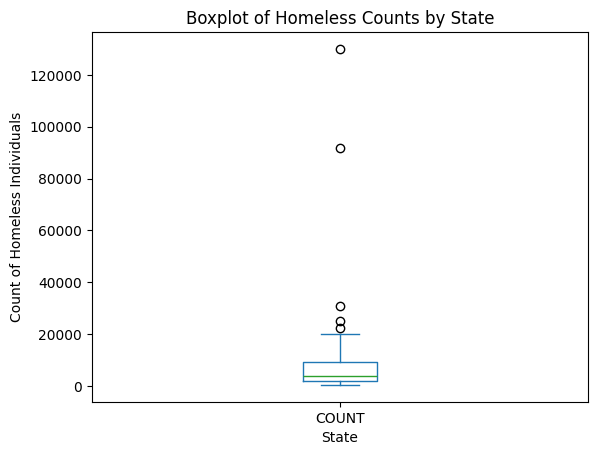

In [11]:
plot_df['COUNT'].plot(kind='box')
plt.title('Boxplot of Homeless Counts by State')
plt.xlabel('State')
plt.ylabel('Count of Homeless Individuals')

Text(0, 0.5, 'Frequency')

Text(0, 0.5, 'Frequency')

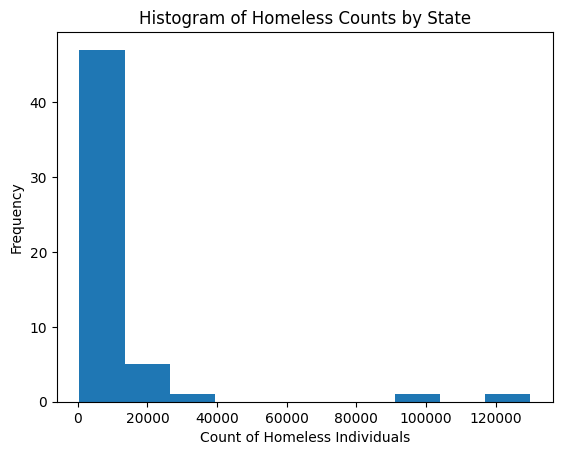

In [12]:
plot_df['COUNT'].plot(kind='hist', bins=10)
plt.title('Histogram of Homeless Counts by State')    
plt.xlabel('Count of Homeless Individuals')
plt.ylabel('Frequency')

In [13]:
states = gpd.read_file('C:\\Users\\josep\\OneDrive\\Documents\\GEOG4670\\Week 4-5\\s_18mr25.shp')
states.head()

,STATE,NAME,FIPS,LON,LAT,geometry
0,AL,Alabama,01,-86.82676,32.79354,"MULTIPOLYGON (((-88.11011 30.25891, -88.10638 ..."
1,AR,Arkansas,05,-92.43920,34.89977,"POLYGON ((-91.62986 36.49921, -91.62849 36.499..."
2,AS,American Samoa,60,-170.37215,-14.26486,"MULTIPOLYGON (((-168.14924 -14.53377, -168.148..."
3,AZ,Arizona,04,-111.66457,34.29323,"POLYGON ((-110.4909 37.00361, -110.4875 37.002..."
4,CA,California,06,-119.60818,37.24537,"MULTIPOLYGON (((-118.4262 32.79973, -118.42634..."


In [14]:
gdf_merge = states.merge(df_OverallHomeless[['STATE','COUNT']], on='STATE', how='left')

In [15]:
gdf_states=gdf_merge[['STATE', 'COUNT']].dropna().copy()

In [16]:
gdf_merge.head(55)

,STATE,NAME,FIPS,LON,LAT,geometry,COUNT
0,AL,Alabama,01,-86.826760,32.793540,"MULTIPOLYGON (((-88.11011 30.25891, -88.10638 ...",3434.0
1,AR,Arkansas,05,-92.439200,34.899770,"POLYGON ((-91.62986 36.49921, -91.62849 36.499...",2712.0
2,AS,American Samoa,60,-170.372150,-14.264860,"MULTIPOLYGON (((-168.14924 -14.53377, -168.148...",NaN
3,AZ,Arizona,04,-111.664570,34.293230,"POLYGON ((-110.4909 37.00361, -110.4875 37.002...",9865.0
4,CA,California,06,-119.608180,37.245370,"MULTIPOLYGON (((-118.4262 32.79973, -118.42634...",129972.0
5,CO,Colorado,08,-105.547830,38.998550,"POLYGON ((-106.8756 41.00301, -106.8585 41.002...",10857.0
6,CT,Connecticut,09,-72.726230,41.621960,"MULTIPOLYGON (((-73.62247 40.9843, -73.62209 4...",3976.0
7,DC,District of Columbia,11,-77.014640,38.909320,"MULTIPOLYGON (((-77.03097 38.80826, -77.0311 3...",6904.0
8,DE,Delaware,10,-75.505920,38.995590,"MULTIPOLYGON (((-75.22731 38.58854, -75.22744 ...",1082.0
9,GA,Georgia,13,-83.448480,32.651550,"MULTIPOLYGON (((-81.49619 30.73234, -81.49648 ...",9499.0


<Axes: >

<Axes: >

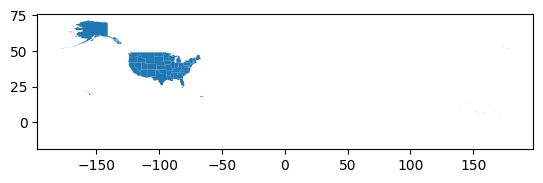

In [17]:
states.plot()

gdf columns: Index(['STATE', 'NAME', 'FIPS', 'LON', 'LAT', 'geometry', 'COUNT'], dtype='str')


gdf columns: Index(['STATE', 'NAME', 'FIPS', 'LON', 'LAT', 'geometry', 'COUNT'], dtype='str')


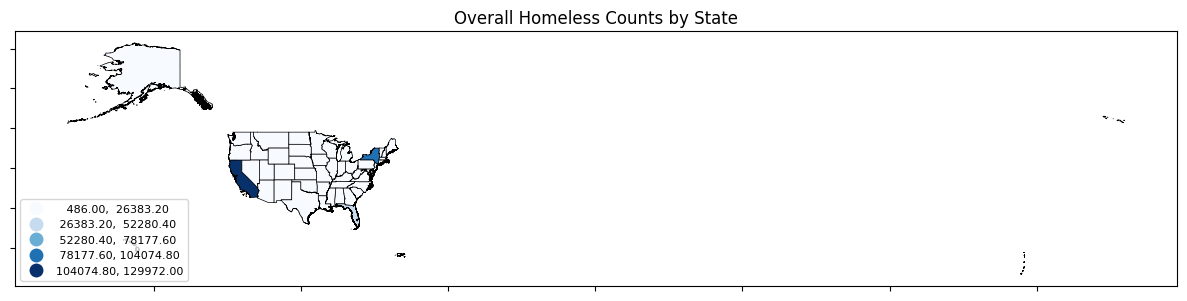

In [18]:
import mapclassify
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
ax.set_title('Overall Homeless Counts by State')
ax.set_xticklabels([])
ax.set_yticklabels([])


df['COUNT'] = pd.to_numeric(df['COUNT'], errors='coerce')
gdf = states.merge(df[['STATE','COUNT']], on='STATE')
print('gdf columns:', gdf.columns)


schemes = ['equal_interval']
gdf.plot(
    ax=ax,
    column='COUNT',
    scheme=schemes[0],
    legend=True,
    cmap='Blues',
    edgecolor='black',
    linewidth=0.5,
    markersize=0.1,
    legend_kwds={'loc': 'lower left', 'fontsize': 8},
)
plt.title('Overall Homeless Counts by State')
plt.show()
#Due to California's relativelyn high count of homeless individuals, using equal interval makes it appear that most states have very little homelessness while one factor that likely plays into this is California's relatively high popuation.

gdf columns: Index(['STATE', 'NAME', 'FIPS', 'LON', 'LAT', 'geometry', 'COUNT'], dtype='str')


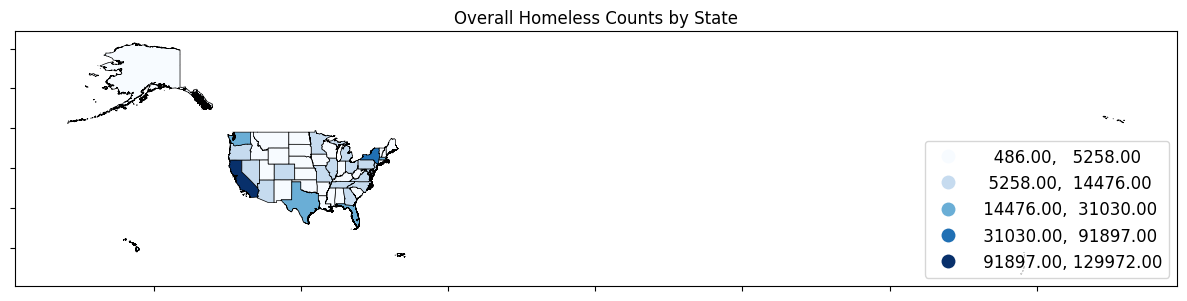

In [30]:
import mapclassify
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
ax.set_title('Overall Homeless Counts by State')
ax.set_xticklabels([])
ax.set_yticklabels([])


df['COUNT'] = pd.to_numeric(df['COUNT'], errors='coerce')
gdf = states.merge(df[['STATE','COUNT']], on='STATE')
print('gdf columns:', gdf.columns)


schemes = ['natural_breaks']
gdf.plot(
    ax=ax,
    column='COUNT',
    scheme=schemes[0],
    legend=True,
    cmap='Blues',
    edgecolor='black',
    linewidth=0.5,
    markersize=0.1,
    legend_kwds={'loc': 'lower right', 'fontsize': 12},
)
plt.title('Overall Homeless Counts by State')
plt.show()
#This map seems much more useful for soome visual analysis of my data since thye natural breaks help create a more even spread across the different categories of maps.